# Library 

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Get the dataset

In [3]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Check the dataset

In [4]:
df.isnull().sum()
df.duplicated().sum()
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# Clean the dataset


In [6]:
def remove_html(text):
    clean = re.sub(r'<.*?>', '', text)
    return clean

In [7]:
def remove_special_char(text):
    clean = re.sub(r'[^a-zA-Z\s]', '', text)
    return clean

In [8]:
def tokenize(text):
    token = text.split()
    return token

In [9]:
def clean_text(text):
    text = remove_html(text)
    text = remove_special_char(text)
    text = text.lower()
    token = tokenize(text)
    return token

# Normalization 

In [10]:
stop_word = set(stopwords.words('english'))

def remove_stopword(text):
    filtered = [word for word in text if word not in stop_word]
    return filtered

In [11]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):

    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize(text_list):
    result = []

    tagged_words = nltk.pos_tag(text_list)
    
    for word, tag in tagged_words:
        wntag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wntag)
        result.append(lemma)
        
    return result

# Checkpoint testing

In [12]:
def preprocessing(text):
    text = remove_html(text)
    text = remove_special_char(text)
    text = text.lower()
    tokens = tokenize(text)
    
    tokens = remove_stopword(tokens)
    tokens = lemmatize(tokens)
    return tokens

# Get the data column and make it usable

In [13]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df['clean'] = df['review'].apply(lambda r: ' '.join(preprocessing(r)))

In [14]:
df.head()

,review,sentiment,label,clean
0,One of the other reviewers has mentioned that ...,positive,1,one reviewer mention watch oz episode youll ho...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,positive,1,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,0,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter matteis love time money visually stunni...


# Train and test data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (40000,)
Test size: (10000,)


# Bayes classification

## One Hot Encoding

In [16]:
encoder = CountVectorizer(binary=True)

X_train_encoded=encoder.fit_transform(X_train)
X_test_encoded=encoder.transform(X_test)

In [50]:
text_pipeline_bayes_one = Pipeline(
    steps=[
        ("encoding", CountVectorizer(binary=True,stop_words='english', ngram_range=(1, 2), max_features=3000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_one.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [51]:
y_pred_bayes_one = text_pipeline_bayes_one.predict(X_test)
y_proba_bayes_one = text_pipeline_bayes_one.predict_proba(X_test)

In [52]:
results_bayes_one = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_one,
    "predicted_probability_positive": y_proba_bayes_one[:,1]
})

results_bayes_one.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,2.516619e-02
1,0,1,9.678907e-01
2,1,1,9.995454e-01
3,0,0,7.020199e-03
4,0,0,1.541406e-04
5,0,0,7.941943e-05
6,0,0,1.151916e-04
7,0,1,6.729487e-01
8,0,0,3.648092e-01
9,0,0,1.317856e-10


#### Accuracy, Precision, Recall, F1-score of OneHotEncoding

In [53]:
accuracy_bayes_one = accuracy_score(y_test, y_pred_bayes_one)
precision_bayes_one = precision_score(y_test, y_pred_bayes_one)
recall_bayes_one = recall_score(y_test, y_pred_bayes_one)
f1_bayes_one = f1_score(y_test, y_pred_bayes_one)

print(f"Accuracy:  {accuracy_bayes_one}")
print(f"Precision: {precision_bayes_one}")
print(f"Recall:    {recall_bayes_one}")
print(f"F1-score:  {f1_bayes_one}")

Accuracy:  0.8443
Precision: 0.8406886997823075
Recall:    0.8496
F1-score:  0.8451208594449419


In [54]:
print(classification_report(
    y_test,
    y_pred_bayes_one,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84      5000
    Positive       0.84      0.85      0.85      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



#### Test and predic score

In [55]:
y_train_bayens_one = text_pipeline_bayes_one.predict(X_train)
train_score = accuracy_score(y_train, y_train_bayens_one)

test_score = accuracy_score(y_test, y_pred_bayes_one)

print(f"Training Score: {train_score:.4f}")
print(f"Testing Score: {test_score:.4f}")

Training Score: 0.8471
Testing Score: 0.8443


#### Confusion matrix of OneHotEncoding

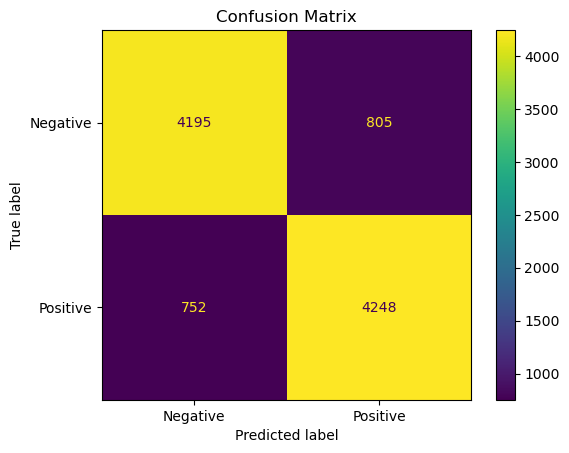

In [56]:
cm_bayes_one = confusion_matrix(y_test, y_pred_bayes_one)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_one,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Bag of Words

In [57]:
counter = CountVectorizer()

X_train_counted = counter.fit_transform(X_train)
X_test_counted = counter.transform(X_test)

In [58]:
text_pipeline_bayes_bag = Pipeline(
    steps=[
        ("encoding", CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=3000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_bag.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [59]:
y_pred_bayes_bag = text_pipeline_bayes_bag.predict(X_test)
y_proba_bayes_bag = text_pipeline_bayes_bag.predict_proba(X_test)

In [60]:
results_bayes_bag = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_bag,
    "predicted_probability_positive": y_proba_bayes_bag[:,1]
})

results_bayes_bag.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,3.917258e-03
1,0,1,9.599465e-01
2,1,1,9.994418e-01
3,0,0,2.315091e-03
4,0,0,2.328389e-05
5,0,0,6.229496e-05
6,0,0,3.844747e-05
7,0,1,6.623249e-01
8,0,0,4.111694e-01
9,0,0,2.198646e-16


#### Accuracy, Precision, Recall, F1-score of Bag of Words

In [61]:
accuracy_bayes_bag = accuracy_score(y_test, y_pred_bayes_bag)
precision_bayes_bag = precision_score(y_test, y_pred_bayes_bag)
recall_bayes_bag = recall_score(y_test, y_pred_bayes_bag)
f1_bayes_bag = f1_score(y_test, y_pred_bayes_bag)

print(f"Accuracy:  {accuracy_bayes_bag}")
print(f"Precision: {precision_bayes_bag}")
print(f"Recall:    {recall_bayes_bag}")
print(f"F1-score:  {f1_bayes_bag}")

Accuracy:  0.8346
Precision: 0.8314183835182251
Recall:    0.8394
F1-score:  0.835390127388535


In [62]:
print(classification_report(
    y_test,
    y_pred_bayes_bag,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83      5000
    Positive       0.83      0.84      0.84      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



#### Test and predic score

In [63]:
y_train_bayens_bag = text_pipeline_bayes_bag.predict(X_train)
train_score = accuracy_score(y_train, y_train_bayens_bag)

test_score = accuracy_score(y_test, y_pred_bayes_bag)

print(f"Training Score: {train_score:.4f}")
print(f"Testing Score: {test_score:.4f}")

Training Score: 0.8395
Testing Score: 0.8346


#### Confusion matrix of Bag of Words

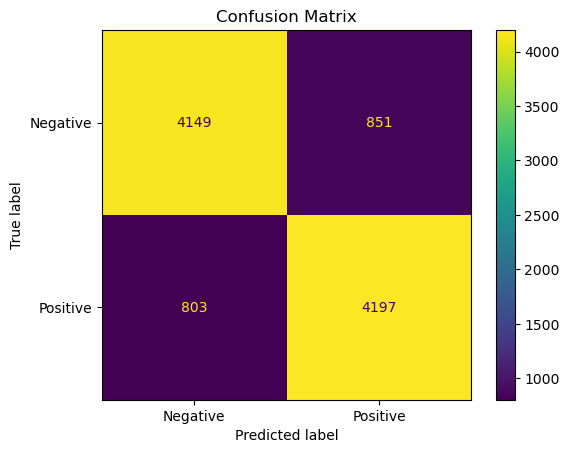

In [64]:
cm_bayes_bag = confusion_matrix(y_test, y_pred_bayes_bag)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_bag,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## TF-IDF

In [65]:
vectorizer = TfidfVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [66]:
text_pipeline_bayes_tfidf = Pipeline(
    steps=[
        ("encoding", TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=3000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_tfidf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [67]:
y_pred_bayes_tfidf = text_pipeline_bayes_tfidf.predict(X_test)
y_proba_bayes_tfidf = text_pipeline_bayes_tfidf.predict_proba(X_test)

In [68]:
results_bayes_tfidf = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_tfidf,
    "predicted_probability_positive": y_proba_bayes_tfidf[:,1]
})

results_bayes_tfidf.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,0.305598
1,0,1,0.644356
2,1,1,0.772006
3,0,0,0.337165
4,0,0,0.217790
5,0,0,0.154761
6,0,0,0.308604
7,0,1,0.595521
8,0,0,0.487347
9,0,0,0.073370


#### Accuracy, Precision, Recall, F1-score of TF - IDF

In [69]:
accuracy_bayes_tfidf = accuracy_score(y_test, y_pred_bayes_tfidf)
precision_bayes_tfidf = precision_score(y_test, y_pred_bayes_tfidf)
recall_bayes_tfidf = recall_score(y_test, y_pred_bayes_tfidf)
f1_bayes_tfidf = f1_score(y_test, y_pred_bayes_tfidf)

print(f"Accuracy:  {accuracy_bayes_tfidf}")
print(f"Precision: {precision_bayes_tfidf}")
print(f"Recall:    {recall_bayes_tfidf}")
print(f"F1-score:  {f1_bayes_tfidf}")

Accuracy:  0.8416
Precision: 0.8306233062330624
Recall:    0.8582
F1-score:  0.8441865040330514


In [70]:
print(classification_report(
    y_test,
    y_pred_bayes_tfidf,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.85      0.82      0.84      5000
    Positive       0.83      0.86      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



#### Test and predic score

In [71]:
y_train_bayens_tfidf = text_pipeline_bayes_tfidf.predict(X_train)
train_score = accuracy_score(y_train, y_train_bayens_tfidf)

test_score = accuracy_score(y_test, y_pred_bayes_tfidf)

print(f"Training Score: {train_score:.4f}")
print(f"Testing Score: {test_score:.4f}")

Training Score: 0.8500
Testing Score: 0.8416


#### Confusion matrix of TF-IDF

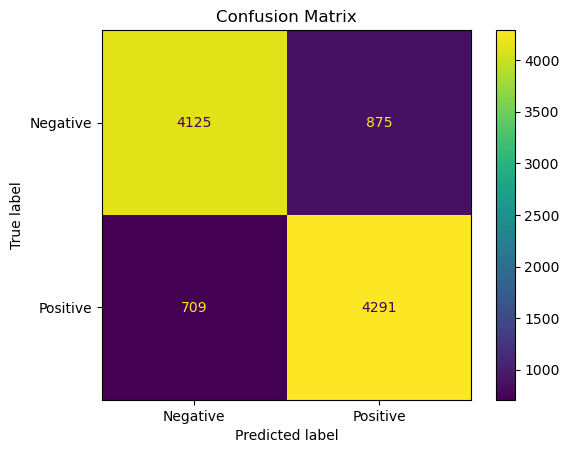

In [72]:
cm_bayes_tfidf = confusion_matrix(y_test, y_pred_bayes_tfidf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_tfidf,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()